In [63]:
# Step 1: Imports
import sympy as sp

# Step 2: Define coordinates
x, y = sp.symbols('x y')          # Cartesian coordinates
r, theta = sp.symbols('r theta')  # Polar coordinates

# Step 3: Define metrics

# 3a: Cartesian metric (flat space)
g_cartesian = sp.Matrix([[1, 0],
                         [0, 1]])

# 3b: Polar metric (ds^2 = dr^2 + r^2 dtheta^2)
g_polar = sp.Matrix([[1, 0],
                     [0, r**2]])

# Step 4: Compute inverse metric
g_cartesian_inv = g_cartesian.inv()
g_polar_inv = g_polar.inv()

# Step 5: Helper function for Christoffel symbols
def christoffel_symbols(coords, g, g_inv):
    n = len(coords)
    Gamma = {}
    for i in range(n):
        for j in range(n):
            for k in range(n):
                expr = 0
                for l in range(n):
                    expr += g_inv[i, l] * (sp.diff(g[l, j], coords[k])
                                           + sp.diff(g[l, k], coords[j])
                                           - sp.diff(g[j, k], coords[l]))
                Gamma[(i,j,k)] = sp.simplify(expr / 2)
    return Gamma

# Step 6: Compute Christoffel symbols
Gamma_cartesian = christoffel_symbols([x, y], g_cartesian, g_cartesian_inv)
Gamma_polar = christoffel_symbols([r, theta], g_polar, g_polar_inv)

# Step 7: Display non-zero Christoffel symbols nicely
def print_nonzero_christoffel(Gamma, coords):
    print("Non-zero Christoffel symbols:")
    for key, value in Gamma.items():
        if value != 0:
            i, j, k = key
            print(f"Γ^{coords[i]}_{coords[j]}{coords[k]} = {value}")

print("Cartesian coordinates:")
print_nonzero_christoffel(Gamma_cartesian, ['x','y'])

print("\nPolar coordinates:")
print_nonzero_christoffel(Gamma_polar, ['r','theta'])



Cartesian coordinates:
Non-zero Christoffel symbols:

Polar coordinates:
Non-zero Christoffel symbols:
Γ^r_thetatheta = -r
Γ^theta_rtheta = 1/r
Γ^theta_thetar = 1/r


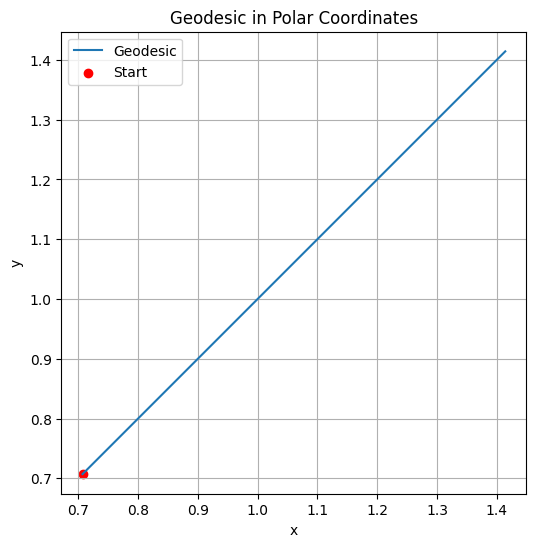

In [70]:
# Step 1: Imports for numerical integration and plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Step 2: Geodesic equations in polar coordinates
# coords = [r, theta], velocities = [dr/dt, dtheta/dt]

def geodesic_ode(t, Y):
    r, theta, dr_dt, dtheta_dt = Y
    # Christoffel symbols
    d2r_dt2 = r * dtheta_dt**2  # Γ^r_θθ = -r
    d2theta_dt2 = -2 * dr_dt * dtheta_dt / r  # Γ^theta_rtheta = 1/r, factor 2 for symmetry
    
    return [dr_dt, dtheta_dt, d2r_dt2, d2theta_dt2]

# Step 3: Function to convert polar to Cartesian for plotting
def polar_to_cartesian(r_vals, theta_vals):
    x_vals = r_vals * np.cos(theta_vals)
    y_vals = r_vals * np.sin(theta_vals)
    return x_vals, y_vals

# Step 4: Initial conditions and integration
# Example: start at r=1, theta=0, moving radially outward with dr/dt=0.5, dtheta/dt=1
# Y0 = [1.0, 0.0, 0.5, 1.0]  # [r, theta, dr/dt, dtheta/dt]
Y0 = [1.0, np.pi / 4.0, 1.0, 0.0]
t_span = (0, 1)  # time range for integration (intitally 5)
t_eval = np.linspace(t_span[0], t_span[1], 200)

sol = solve_ivp(geodesic_ode, t_span, Y0, t_eval=t_eval)

# Step 5: Convert to Cartesian for plotting
x_vals, y_vals = polar_to_cartesian(sol.y[0], sol.y[1])

# Step 6: Plot the geodesic
plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals, label='Geodesic')
plt.scatter([Y0[0]*np.cos(Y0[1])], [Y0[0]*np.sin(Y0[1])], color='red', label='Start')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Geodesic in Polar Coordinates')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
